#### Step 1 — Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from mplsoccer import Pitch, Sbopen

### Step 2 — Load the Football Dataset

We will use StatsBomb Open Data (free football event data).

In [34]:
# Create parser:
parser = Sbopen()

In [35]:
# Load competitions:
competitions = parser.competition()

competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [36]:
# Example filter:
competitions[competitions['competition_name'].str.contains("Liga", case=False)]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585


### Step 3 — Load Matches

After finding the competition_id and season_id:

In [37]:
matches = parser.match(competition_id=11, season_id=90)

matches[['match_id','home_team_name','away_team_name','match_date']].head()

,match_id,home_team_name,away_team_name,match_date
0,3773386,Deportivo Alavés,Barcelona,2020-10-31
1,3773565,Granada,Barcelona,2021-01-09
2,3773457,Barcelona,Celta Vigo,2021-05-16
3,3773631,Real Betis,Barcelona,2021-02-07
4,3773665,Osasuna,Barcelona,2021-03-06


In [38]:
# Find Barcelona matches:
barca_matches = matches[
    (matches['home_team_name'].str.contains("Barcelona", case=False)) |
    (matches['away_team_name'].str.contains("Barcelona", case=False))
]

barca_matches

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,3773386,2020-10-31,2020-10-31 21:00:00,1,1,available,available,2023-07-25 03:54:59.280826,2023-07-25 04:25:41.348202,8,...,1,Regular Season,348,Estadio de Mendizorroza,214,Spain,NaN,NaN,NaN,NaN
1,3773565,2021-01-09,2021-01-09 18:30:00,0,4,available,available,2023-07-25 03:51:37.437064,2023-07-25 04:30:16.058384,18,...,1,Regular Season,4667,Estadio Nuevo Los Cármenes,214,Spain,2602.0,Ricardo De Burgos Bengoetxea,214.0,Spain
2,3773457,2021-05-16,2021-05-16 18:30:00,1,2,available,available,2022-12-02 09:26:39.496362,2023-04-27 23:03:53.506485,37,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,NaN,NaN,NaN,NaN
3,3773631,2021-02-07,2021-02-07 21:00:00,2,3,available,available,2023-07-25 03:47:44.278651,2023-07-25 03:56:34.733180,22,...,1,Regular Season,352,Estadio Benito Villamarín,214,Spain,NaN,NaN,NaN,NaN
4,3773665,2021-03-06,2021-03-06 21:00:00,0,2,available,available,2022-12-02 08:46:42.897589,2023-04-28 02:57:03.412841,26,...,1,Regular Season,4650,Estadio El Sadar,214,Spain,2402.0,Guillermo Cuadra Fernández,214.0,Spain
5,3773497,2021-04-10,2021-04-10 21:00:00,2,1,available,available,2022-12-02 09:04:21.859831,2023-04-28 01:35:16.051381,30,...,1,Regular Season,5341,Estadio Alfredo Di Stéfano,214,Spain,183.0,Jesús Gil Manzano,214.0,Spain
6,3773660,2020-12-13,2020-12-13 21:00:00,1,0,available,available,2022-12-01 14:49:02.748131,2023-04-28 06:01:10.173360,13,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,2602.0,Ricardo De Burgos Bengoetxea,214.0,Spain
7,3773593,2020-09-27,2020-09-27 21:00:00,4,0,available,available,2023-07-25 04:01:57.790373,2023-07-25 04:44:03.367478,3,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,2402.0,Guillermo Cuadra Fernández,214.0,Spain
8,3773466,2020-10-01,2020-10-01 21:30:00,0,3,available,available,2023-07-25 03:55:25.794505,2023-07-25 04:40:53.635540,4,...,1,Regular Season,653,Abanca-Balaídos,214,Spain,2728.0,Carlos del Cerro Grande,214.0,Spain
9,3773585,2020-10-24,2020-10-24 16:00:00,1,3,available,available,2023-07-25 03:53:35.185506,2023-07-25 04:29:21.140321,7,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,2434.0,Juan Martínez Munuera,214.0,Spain


In [39]:
# Pick one match.
match_id = barca_matches.iloc[0]['match_id']

### Step 4 — Load Event Data

In [40]:
events, related, freeze, tactics = parser.event(match_id)

events.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,pass_no_touch,ball_recovery_recovery_failure,dribble_nutmeg,pass_cut_back,shot_open_goal,bad_behaviour_card_id,bad_behaviour_card_name,substitution_replacement_id,substitution_replacement_name,foul_committed_offensive
0,d2bccfa7-36d1-408a-8146-73e352d06887,1,1,00:00:00,0,0,1,0.000000,3773386,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2f5fae8c-fc9b-4319-914a-884e71023c3b,2,1,00:00:00,0,0,1,0.000000,3773386,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,e864ed70-94fa-4f91-bc8f-a70bde42b33c,3,1,00:00:00,0,0,1,0.000000,3773386,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9425b991-43aa-41b3-8ed7-799c2d799967,4,1,00:00:00,0,0,1,0.000000,3773386,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,208f072d-cffa-4575-bd73-e9e9384c8fe1,5,1,00:00:00.689000,0,0,2,0.963571,3773386,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 5 — Extract Barcelona Passes

In [41]:
barca_team = events[
    events['team_name'].str.contains("Barcelona", case=False)
]['team_name'].mode()[0]

passes = events[
    (events['team_name'] == barca_team) &
    (events['type_name'] == 'Pass')
]

### Step 6 — keep only completed Barcelona passes

In [46]:
events.columns.tolist()

['id',
 'index',
 'period',
 'timestamp',
 'minute',
 'second',
 'possession',
 'duration',
 'match_id',
 'type_id',
 'type_name',
 'possession_team_id',
 'possession_team_name',
 'play_pattern_id',
 'play_pattern_name',
 'team_id',
 'team_name',
 'tactics_formation',
 'player_id',
 'player_name',
 'position_id',
 'position_name',
 'pass_recipient_id',
 'pass_recipient_name',
 'pass_length',
 'pass_angle',
 'pass_height_id',
 'pass_height_name',
 'end_x',
 'end_y',
 'body_part_id',
 'body_part_name',
 'sub_type_id',
 'sub_type_name',
 'x',
 'y',
 'under_pressure',
 'outcome_id',
 'outcome_name',
 'counterpress',
 'foul_committed_advantage',
 'foul_won_advantage',
 'aerial_won',
 'pass_switch',
 'technique_id',
 'technique_name',
 'out',
 'off_camera',
 'pass_deflected',
 'pass_cross',
 'pass_assisted_shot_id',
 'pass_shot_assist',
 'shot_one_on_one',
 'shot_statsbomb_xg',
 'end_z',
 'shot_key_pass_id',
 'goalkeeper_position_id',
 'goalkeeper_position_name',
 'foul_won_defensive',
 'fou

In [47]:
events[['type_name','outcome_name']].drop_duplicates().head(20)

,type_name,outcome_name
0,Starting XI,NaN
2,Half Start,NaN
4,Pass,NaN
5,Ball Receipt,NaN
8,Carry,NaN
23,Pressure,NaN
49,Pass,Incomplete
50,Ball Receipt,Incomplete
57,Ball Recovery,NaN
102,Dribbled Past,NaN


In [48]:
# Check Barcelona team name first
events['team_name'].dropna().unique()

array(['Deportivo Alavés', 'Barcelona'], dtype=object)

In [56]:
barca_team = events[
    events['team_name'].str.contains("Barcelona", case=False, na=False)
]['team_name'].mode()[0]

barca_team

'Barcelona'

In [57]:
# filter Barcelona passes:
passes = events[
    (events['team_name'] == barca_team) &
    (events['type_name'] == 'Pass')
].copy()

passes[['player_name', 'pass_recipient_name', 'outcome_name', 'x', 'y', 'end_x', 'end_y']].head(10)

,player_name,pass_recipient_name,outcome_name,x,y,end_x,end_y
4,Antoine Griezmann,Sergio Busquets i Burgos,NaN,61.0,40.1,50.0,45.4
6,Sergio Busquets i Burgos,Frenkie de Jong,NaN,49.4,44.9,47.1,29.6
9,Frenkie de Jong,Gerard Piqué Bernabéu,NaN,48.1,29.6,35.5,50.6
12,Gerard Piqué Bernabéu,Clément Lenglet,NaN,44.3,50.2,41.0,29.7
15,Clément Lenglet,Sergio Busquets i Burgos,NaN,49.0,28.7,57.8,33.5
17,Sergio Busquets i Burgos,Gerard Piqué Bernabéu,NaN,57.1,33.1,42.7,51.2
20,Gerard Piqué Bernabéu,Clément Lenglet,NaN,49.1,52.5,42.4,29.3
24,Clément Lenglet,Jordi Alba Ramos,NaN,41.3,29.2,41.8,12.5
28,Jordi Alba Ramos,Sergio Busquets i Burgos,NaN,37.1,14.6,41.8,28.3
31,Sergio Busquets i Burgos,Sergi Roberto Carnicer,NaN,42.4,27.6,35.2,59.9


In [59]:
# Now keep only completed passes.
completed_passes = passes[passes['outcome_name'].isna()].copy()

In [60]:
# Clean missing values:
completed_passes = completed_passes.dropna(
    subset=['player_name', 'pass_recipient_name', 'x', 'y', 'end_x', 'end_y']
)

In [61]:
# Check result:
print("All passes:", len(passes))
print("Completed passes:", len(completed_passes))

completed_passes[['player_name', 'pass_recipient_name', 'outcome_name']].head(10)

All passes: 880
Completed passes: 784


,player_name,pass_recipient_name,outcome_name
4,Antoine Griezmann,Sergio Busquets i Burgos,NaN
6,Sergio Busquets i Burgos,Frenkie de Jong,NaN
9,Frenkie de Jong,Gerard Piqué Bernabéu,NaN
12,Gerard Piqué Bernabéu,Clément Lenglet,NaN
15,Clément Lenglet,Sergio Busquets i Burgos,NaN
17,Sergio Busquets i Burgos,Gerard Piqué Bernabéu,NaN
20,Gerard Piqué Bernabéu,Clément Lenglet,NaN
24,Clément Lenglet,Jordi Alba Ramos,NaN
28,Jordi Alba Ramos,Sergio Busquets i Burgos,NaN
31,Sergio Busquets i Burgos,Sergi Roberto Carnicer,NaN


### Step 7 — Calculate Average Player Positions

In [54]:
avg_positions = (
    completed_passes
    .groupby('player_name')
    .agg(
        avg_x=('x','mean'),
        avg_y=('y','mean'),
        passes=('player_name','count')
    )
    .reset_index()
)

avg_positions.head()

,player_name,avg_x,avg_y,passes
0,Anssumane Fati,89.775676,17.781081,37
1,Antoine Griezmann,83.528125,32.331250,32
2,Clément Lenglet,52.490566,23.769811,53
3,Francisco António Machado Mota de Castro Trincão,89.705882,64.458824,34
4,Frenkie de Jong,62.803093,25.576289,97


### Step 8 — Build Pass Connections

In [63]:
pass_links = (
    completed_passes
    .groupby(['player_name', 'pass_recipient_name'])
    .size()
    .reset_index(name='pass_count')
    .sort_values('pass_count', ascending=False)
)

pass_links.head(10)

,player_name,pass_recipient_name,pass_count
52,Gerard Piqué Bernabéu,Clément Lenglet,22
61,Gerard Piqué Bernabéu,Sergi Roberto Carnicer,21
124,Sergi Roberto Carnicer,Francisco António Machado Mota de Castro Trincão,21
126,Sergi Roberto Carnicer,Gerard Piqué Bernabéu,18
130,Sergi Roberto Carnicer,Ousmane Dembélé,17
54,Gerard Piqué Bernabéu,Frenkie de Jong,17
45,Frenkie de Jong,Miralem Pjanić,17
41,Frenkie de Jong,Gerard Piqué Bernabéu,17
94,Miralem Pjanić,Lionel Andrés Messi Cuccittini,16
91,Miralem Pjanić,Frenkie de Jong,14


### Step 9 — Build the Network Graph

In [65]:
G = nx.DiGraph()

# Add players as nodes
for _, row in avg_positions.iterrows():
    G.add_node(
        row['player_name'],
        x=row['avg_x'],
        y=row['avg_y'],
        passes=row['passes']
    )

# Add pass connections
for _, row in pass_links.iterrows():
    G.add_edge(
        row['player_name'],
        row['pass_recipient_name'],
        weight=row['pass_count']
    )

print("Players:", G.number_of_nodes())
print("Connections:", G.number_of_edges())

Players: 16
Connections: 149


### Step 10 — Calculate Tactical Metrics

In [67]:
# Team Length
team_length = avg_positions['avg_x'].max() - avg_positions['avg_x'].min()

In [68]:
# Team Width
team_width = avg_positions['avg_y'].max() - avg_positions['avg_y'].min()

In [70]:
# Assortativity
assortativity = nx.degree_assortativity_coefficient(G)

In [71]:
# Print them:
print("Team length:", team_length)
print("Team width:", team_width)
print("Assortativity:", assortativity)

Team length: 77.67105263157895
Team width: 59.945464852607714
Assortativity: -0.2556512585348767


### Step 11 — Plot the Passing Network

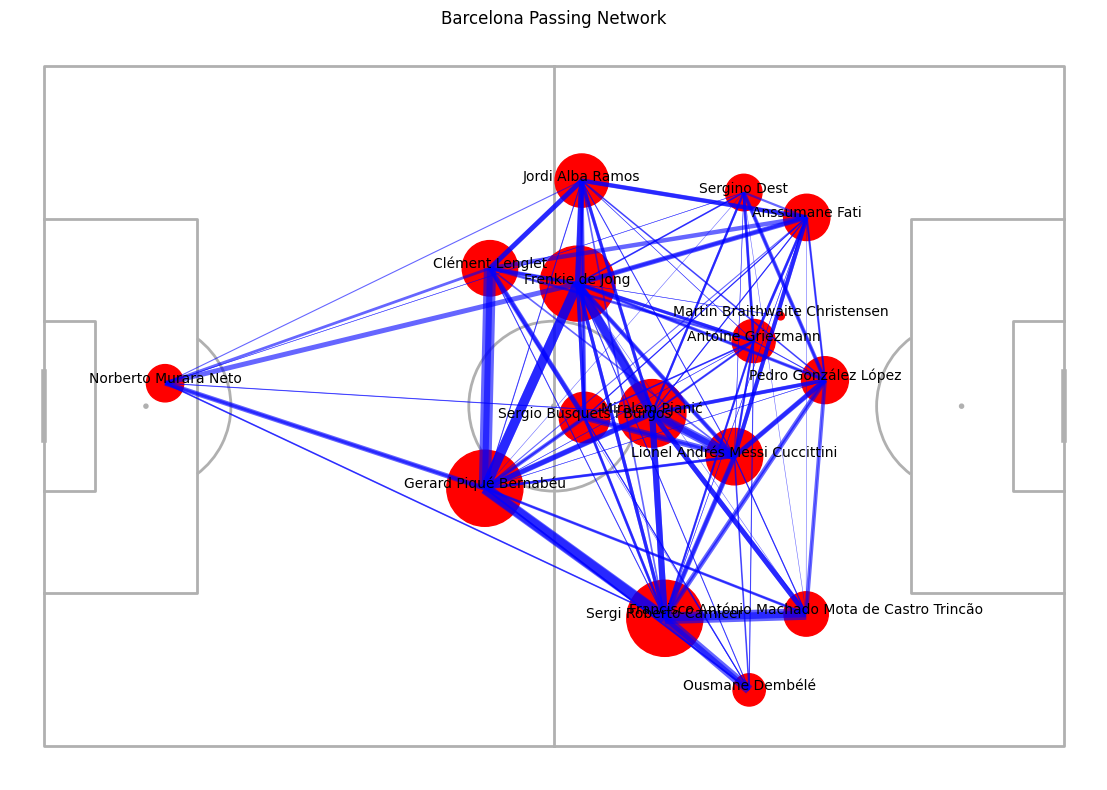

In [72]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(12,8))

# Draw passes
for u, v, data in G.edges(data=True):

    x1 = G.nodes[u]['x']
    y1 = G.nodes[u]['y']
    x2 = G.nodes[v]['x']
    y2 = G.nodes[v]['y']

    pitch.lines(
        x1, y1, x2, y2,
        lw=data['weight']*0.4,
        color="blue",
        alpha=0.6,
        ax=ax
    )

# Draw players
node_x = [G.nodes[n]['x'] for n in G.nodes]
node_y = [G.nodes[n]['y'] for n in G.nodes]
sizes = [G.nodes[n]['passes']*30 for n in G.nodes]

pitch.scatter(node_x, node_y, s=sizes, color="red", ax=ax)

for n in G.nodes:
    ax.text(G.nodes[n]['x'], G.nodes[n]['y'], n, ha='center')

plt.title("Barcelona Passing Network")
plt.show()

### Step 12 — Save Results

In [74]:
# Save network figure:
fig.savefig("../outputs/barcelona_passing_network.png", dpi=300)

In [75]:
# Save data tables:
avg_positions.to_csv("../data/player_positions.csv", index=False)
pass_links.to_csv("../data/pass_links.csv", index=False)